In [1]:
"""Phase-1 validation: smile(+keystone) truth via gert dispersion, retrieve with
dispersion in the state, compare nonlinear vs linear bias for XCO2/XCH4/XCO."""
import sys, time, numpy as np
from pathlib import Path
sys.path.insert(0, "/scratch/scrowel3_lab/geocarb_simulator")
GERT = Path("/scratch/scrowel3_lab/gert")
sys.path.insert(0, str(GERT))

import geosat_geometry as gg
from geocarb_gert import (build_geocarb_instrument, sample_geometries,
                          reference_atmosphere, albedo_for)
import gert
from gert.forward_model import ForwardModel
from gert.rt_solver import SingleScatterSolver
from gert.retrieval import StateVector, GERTRetrieval
from gert.instrument import FlatSNR
import matplotlib.pyplot as plt

In [2]:
# ---- scene / instrument / geometry ----
block = gg.geocarb_demo(verbose=False)['blocks'][0]
row, col, geo = sample_geometries(block, n=1, seed=0)[0]
inst  = build_geocarb_instrument()
atm   = reference_atmosphere()
absco = gert.ABSCOTable.load_all(str(GERT/'input/absco/absco.h5'))
solar = gert.SolarSpectrum.load(str(GERT/'input/solar/solar.h5'))
nb    = len(inst.windows)
albedo = albedo_for(inst, 'desert')          # per-band Lambertian albedo
GASES = ['co2', 'ch4', 'co', 'h2o']
KEY_FRAC = 20.0 / 1024.0                      # 20-px slit-image growth on 1024-px slit
SMILE_PX = 2.0                                # per-band smile (placeholder, TBD)

fm = ForwardModel(atm, absco, inst, geo, solver=SingleScatterSolver(), solar_spectrum=solar)

In [3]:
def smile_disp_coeffs(eta, keystone_on, fit_order=4):
    """Per-band dispersion coeffs [a0..] (cm-1) for the smile(+keystone) shift at eta."""
    disp = {}
    for b, w in enumerate(inst.windows):
        nu   = np.asarray(w.wn_instrument, float)
        span = w.wn_max - w.wn_min
        f    = (nu - w.wn_min) / span
        dnu_det = span / 1023.0               # detector pixel = band / 1024 px
        stretch2 = (1.0 + KEY_FRAC * f) ** 2 if keystone_on else 1.0
        dv   = -(SMILE_PX * dnu_det) * f * eta**2 / stretch2      # cm-1 per channel
        u    = w.dispersion_unit_coord()
        disp[b] = np.polyfit(u, dv, fit_order)[::-1]              # -> [a0,a1,...]
    return disp

# nominal (undistorted) truth + noise model
res0   = fm.run(albedo=list(albedo), albedo_slope=[0.0]*nb)
y_nom  = res0.y
sigma  = np.maximum(FlatSNR(300.).sigma(res0.R_band, inst.windows), 1e-30)
Sy_inv = np.diag(1.0 / sigma**2)
xtrue  = {g: atm.column_xgas(g) * (1e6 if g == 'co2' else 1e9) for g in ('co2','ch4','co')}
print("truth Xgas:", {g: round(v,2) for g,v in xtrue.items()}, "| n_y =", y_nom.size)

def bias_case(eta, keystone_on, order):
    disp   = smile_disp_coeffs(eta, keystone_on)
    y_dist = fm.run(albedo=list(albedo), albedo_slope=[0.0]*nb, dispersion=disp).y
    sv = StateVector.gas_scaling(prior_albedo=albedo, prior_albedo_slope=np.zeros(nb),
                                 gases=GASES, include_dispersion=True,
                                 dispersion_order=order, dispersion_uncert=2.0)
    # NOTE: dx_norm (not the default chisq<1.01) convergence criterion.
    # chisq-based stopping can declare convergence after a single GN step
    # whenever chisq happens to cross 1.01, even with the step still large
    # (Delta chisq >> 0) -- this produced a spurious discontinuity in the
    # bias(eta) curve around eta=0.70/0.71 where one side took 1 step and
    # the other took 2. dx_norm stops on actual step size instead.
    ret = GERTRetrieval(fm, y_dist, Sy_inv, sv, prior_albedo=albedo,
                        prior_albedo_slope=np.zeros(nb), analytical_jacobians=True,
                        max_iter=12, verbose=False,
                        convergence_criterion='dx_norm', dx_tol=0.01)
    assert ret.analytical_jacobians, "expected analytical jacobians for SingleScatter"
    names = sv.names
    def xgas_bias(scale_vec):
        return {g: xtrue[g] * (scale_vec[names.index(g+'_scale')] - 1.0) for g in ('co2','ch4','co')}
    # nonlinear
    res = ret.run()
    nl = xgas_bias(res.x_ret); nl['_conv'] = res.converged; nl['_chi2'] = float(res.chisq_reduced)
    # linear: dx = G dy at prior
    x0 = sv.prior; y0 = ret._forward(x0); K, _ = ret._jacobian_mixed(x0, y0)
    mask = sv.active_mask; Sa = sv.Sa
    Ka = K[:, mask]; Sai = np.linalg.inv(Sa[np.ix_(mask, mask)])
    KtSi = Ka.T @ Sy_inv; Shat = np.linalg.inv(KtSi @ Ka + Sai)
    dx = np.zeros(len(sv.names)); dx[mask] = Shat @ (KtSi @ (y_dist - y0))
    lin = xgas_bias(x0 + dx)
    return nl, lin, res, y_dist

truth Xgas: {'co2': 415.0, 'ch4': 1900.0, 'co': 100.0} | n_y = 4206


In [4]:
t=time.time()
slit_pos = np.arange(0.0,0.91,0.05)
dct = {}
for eta in slit_pos:
    nl, lin, res, y_dist = bias_case(eta, True, 2)
    dct[np.round(eta, 2)] = (nl, lin, res, y_dist)
    print("\n[validation] eta=%.2f, smile+keystone, order-2  (%.1fs)"%(eta, time.time()-t))
    print("  nonlinear bias:", {g: round(nl[g],4) for g in ('co2','ch4','co')}, "conv=%s chi2=%.3f"%(nl['_conv'],nl['_chi2']))
    print("  linear    bias:", {g: round(lin[g],4) for g in ('co2','ch4','co')})


[validation] eta=0.00, smile+keystone, order-2  (5.2s)
  nonlinear bias: {'co2': np.float64(0.0), 'ch4': np.float64(0.0), 'co': np.float64(0.0)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(0.0), 'ch4': np.float64(0.0), 'co': np.float64(0.0)}



[validation] eta=0.05, smile+keystone, order-2  (10.3s)
  nonlinear bias: {'co2': np.float64(0.0), 'ch4': np.float64(0.0), 'co': np.float64(0.0)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-0.0004), 'ch4': np.float64(-0.0015), 'co': np.float64(-0.0002)}



[validation] eta=0.10, smile+keystone, order-2  (15.4s)
  nonlinear bias: {'co2': np.float64(-0.0), 'ch4': np.float64(-0.0), 'co': np.float64(0.0)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-0.006), 'ch4': np.float64(-0.0234), 'co': np.float64(-0.0039)}



[validation] eta=0.15, smile+keystone, order-2  (22.2s)
  nonlinear bias: {'co2': np.float64(-0.0), 'ch4': np.float64(-0.0), 'co': np.float64(0.0)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-0.0304), 'ch4': np.float64(-0.1185), 'co': np.float64(-0.0196)}



[validation] eta=0.20, smile+keystone, order-2  (28.9s)
  nonlinear bias: {'co2': np.float64(-0.0), 'ch4': np.float64(-0.0), 'co': np.float64(0.0001)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-0.096), 'ch4': np.float64(-0.3743), 'co': np.float64(-0.0619)}


...


[validation] eta=0.70, smile+keystone, order-2  (111.9s)
  nonlinear bias: {'co2': np.float64(-0.0001), 'ch4': np.float64(-0.0002), 'co': np.float64(0.0007)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-14.1882), 'ch4': np.float64(-54.7702), 'co': np.float64(-8.8385)}



[validation] eta=0.75, smile+keystone, order-2  (121.9s)
  nonlinear bias: {'co2': np.float64(-0.0001), 'ch4': np.float64(-0.0002), 'co': np.float64(0.0007)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-18.5797), 'ch4': np.float64(-71.6137), 'co': np.float64(-11.4976)}



[validation] eta=0.80, smile+keystone, order-2  (131.7s)
  nonlinear bias: {'co2': np.float64(-0.0002), 'ch4': np.float64(-0.0001), 'co': np.float64(0.0007)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-23.8634), 'ch4': np.float64(-91.8315), 'co': np.float64(-14.6585)}



[validation] eta=0.85, smile+keystone, order-2  (141.6s)
  nonlinear bias: {'co2': np.float64(-0.0002), 'ch4': np.float64(-0.0001), 'co': np.float64(0.0004)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-30.1198), 'ch4': np.float64(-115.7136), 'co': np.float64(-18.3508)}



[validation] eta=0.90, smile+keystone, order-2  (151.5s)
  nonlinear bias: {'co2': np.float64(-0.0002), 'ch4': np.float64(-0.0002), 'co': np.float64(-0.0008)} conv=True chi2=0.000
  linear    bias: {'co2': np.float64(-37.4188), 'ch4': np.float64(-143.5037), 'co': np.float64(-22.5931)}


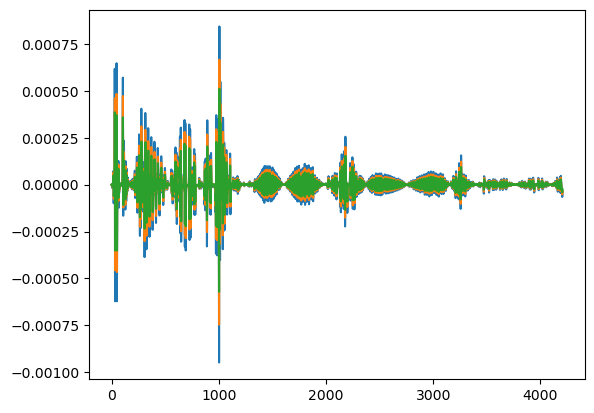

In [5]:
plt.plot(dct[0.9][2].y_ret-dct[0.9][3])
plt.plot(dct[0.8][2].y_ret-dct[0.8][3])
plt.plot(dct[0.7][2].y_ret-dct[0.7][3])



In [6]:
dct[0.7][3].shape


(4206,)

In [7]:
dct[0.9][3][:1050]

array([95.21754502, 95.18877833, 95.17599906, ..., 26.80275421,
       28.34246836, 28.87214021], shape=(1050,))

In [8]:
# Fine eta sweep to pinpoint the eta=0.7 -> 0.8 transition
fine_slit_pos = np.round(np.arange(0.70, 0.901, 0.01), 3)
fine_dct = {}
t0 = time.time()
for eta in fine_slit_pos:
    nl, lin, res, y_dist = bias_case(eta, True, 2)
    fine_dct[eta] = (nl, lin, res, y_dist)
    print("eta=%.3f  chi2=%.4f  conv=%s  co2=%.4f  ch4=%.4f  co=%.4f  (%.1fs)" %
          (eta, nl['_chi2'], nl['_conv'], nl['co2'], nl['ch4'], nl['co'], time.time()-t0))

eta=0.700  chi2=0.0000  conv=True  co2=-0.0001  ch4=-0.0002  co=0.0007  (10.1s)


eta=0.710  chi2=0.0000  conv=True  co2=-0.0001  ch4=-0.0002  co=0.0007  (20.1s)


eta=0.720  chi2=0.0000  conv=True  co2=-0.0001  ch4=-0.0002  co=0.0007  (30.8s)


eta=0.730  chi2=0.0000  conv=True  co2=-0.0001  ch4=-0.0002  co=0.0007  (41.9s)


eta=0.740  chi2=0.0000  conv=True  co2=-0.0001  ch4=-0.0002  co=0.0007  (52.7s)


...

eta=0.860  chi2=0.0000  conv=True  co2=-0.0002  ch4=-0.0001  co=0.0002  (175.1s)


eta=0.870  chi2=0.0000  conv=True  co2=-0.0002  ch4=-0.0001  co=0.0000  (184.9s)


eta=0.880  chi2=0.0000  conv=True  co2=-0.0002  ch4=-0.0002  co=-0.0002  (194.8s)


eta=0.890  chi2=0.0000  conv=True  co2=-0.0002  ch4=-0.0002  co=-0.0005  (206.2s)


eta=0.900  chi2=0.0000  conv=True  co2=-0.0002  ch4=-0.0002  co=-0.0008  (217.1s)


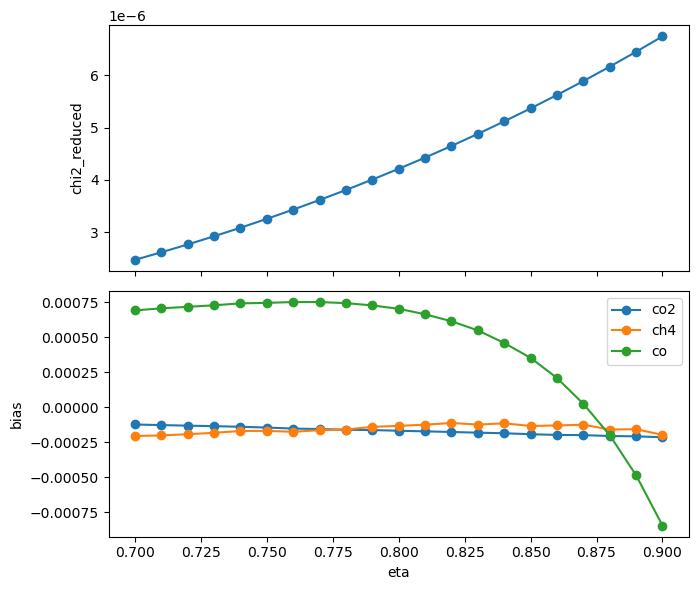

In [9]:
etas   = sorted(fine_dct)
chi2s  = [fine_dct[e][0]['_chi2'] for e in etas]
co2b   = [fine_dct[e][0]['co2']  for e in etas]
ch4b   = [fine_dct[e][0]['ch4']  for e in etas]
cob    = [fine_dct[e][0]['co']   for e in etas]

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7, 6))
ax[0].plot(etas, chi2s, 'o-')
ax[0].set_ylabel('chi2_reduced')
ax[1].plot(etas, co2b, 'o-', label='co2')
ax[1].plot(etas, ch4b, 'o-', label='ch4')
ax[1].plot(etas, cob,  'o-', label='co')
ax[1].set_ylabel('bias')
ax[1].set_xlabel('eta')
ax[1].legend()
plt.tight_layout()